# TEMPO Convergence Analysis

This notebook studies numerical convergence of OQuPy/TEMPO for the pure-dephasing benchmark model. The goal is to isolate the effects of timestep, relative precision, and memory cutoff before using TEMPO for production calculations.

**Notebook map**

1. Imports
2. Generic OQuPy/TEMPO helper
3. Reference model
4. Timestep and precision convergence
5. Convergence plots
6. Memory cutoff convergence


In [1]:
import oqupy as hp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Imports

Load numerical libraries, plotting tools, and OQuPy.

In [2]:
def run_oqupy_dynamics(Hs, A, correlations, rho0, dt, tcut, epsrel, t_end,):
    system = hp.System(Hs)    # SYSTEM
    bath = hp.Bath(A, correlations)    # BATH
    tempo_parameters = hp.TempoParameters(dt=dt, tcut=tcut, epsrel=epsrel)    # TEMPO PARAMETERS
    pt = hp.pt_tempo_compute(bath=bath, start_time=0.0, end_time=t_end, parameters=tempo_parameters)    # PROCESS TENSOR
    dynamics = hp.compute_dynamics(system=system, process_tensor=pt, initial_state=rho0, start_time=0.0)    # DYNAMICS
    states = dynamics.states    # EXTRACT STATES
    times = dynamics.times
    return {"dynamics": dynamics, "process_tensor": pt, "times": times, "states": states,}

## 2. Generic OQuPy/TEMPO helper

Reusable wrapper for constructing the system, bath, TEMPO parameters, and extracting the reduced dynamics.

In [3]:
# =====================================================
# 1. Define physical parameters
# =====================================================
omega0   = 1e-5        # qubit frequency
alpha    = 0.02        # dimensionless coupling strength
omega_c  = 10.0       # cutoff frequency for Ohmic bath
T        = 0.0        # zero temperature

# =====================================================
# 2. System Hamiltonian and coupling operator
# =====================================================
# Use standard Pauli matrices (as numpy arrays)
sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)

H_sys = 0.5 * omega0 * sigma_z   # system Hamiltonian
A = 0.5 * sigma_z                      # coupling operator σ_z
Delta = np.linalg.eigvalsh(A)[-1] - np.linalg.eigvalsh(A)[0] # energy gap of the system Hamiltonian

# =====================================================
# 3. Bath spectral density (Ohmic with exponential cutoff)
# =====================================================
# OQuPy's PowerLawSD creates the correlation function
# for an Ohmic spectral density J(ω)=2α ω e^(-ω/ω_c).
# For s=1, 'alpha' is the dimensionless coupling strength. So we can directly use alpha=0.1 here.
correlations = hp.PowerLawSD(alpha=alpha, zeta=1, cutoff=omega_c, cutoff_type="exponential", temperature=T)

# =====================================================
# 4. Initial state: |+⟩⟨+| = 0.5 * (|0⟩+|1⟩)(⟨0|+⟨1|)
# =====================================================
rho0 = 0.5 * np.ones((2, 2), dtype=complex)


## 3. Reference pure-dephasing model

Define the physical parameters, operators, initial state, and bath correlation used throughout the convergence analysis.

In [4]:
t_test = 3.0

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Converge dt and epsrel to ensure the error is below a certain threshold
# ─────────────────────────────────────────────────────────────────────────────
dt_list = [0.28, 0.26, 0.24, 0.22, 0.20, 0.18, 0.16]
eps_list = [1e-11, 1e-12, 1e-13]
table = []

for dt in dt_list:
    for epsrel in eps_list:

        result = run_oqupy_dynamics(
            H_sys,
            A,
            correlations,
            rho0,
            dt=dt,
            tcut=t_test,      # for this benchmark, avoid memory cutoff error
            epsrel=epsrel,
            t_end=t_test
        )

        times = result["times"]
        states = result["states"]
        coh = np.array([s[0,1] for s in states])

        gamma_R = alpha*np.log(1.0 + (omega_c*times)**2)

        # For the physical Hamiltonian H_int = sigma_z sum g(b+b†):
        coh_exact = coh[0] * np.exp(
            -1j*omega0*times
            -(Delta**2)*gamma_R
        )

        err_max = np.max(np.abs(coh - coh_exact))
        err_final = np.abs(coh[-1] - coh_exact[-1])

        table.append({
            "dt": dt,
            "epsrel": epsrel,
            "max_error": err_max,
            "final_error": err_final,
            "n_steps": len(times)
        })

        print(
            f"dt={dt}, epsrel={epsrel} "
            f"-> max error = {err_max:.3e}, "
            f"final error = {err_final:.3e}"
        )

df = pd.DataFrame(table)

df = df.sort_values(["epsrel", "dt"], ascending=[True, False])

print(df)

--> PT-TEMPO computation:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.1s
--> Compute dynamics:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.0s
dt=0.28, epsrel=1e-11 -> max error = 7.261e-10, final error = 4.729e-10
--> PT-TEMPO computation:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.1s
--> Compute dynamics:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.1s
dt=0.28, epsrel=1e-12 -> max error = 7.271e-10, final error = 6.341e-10
--> PT-TEMPO computation:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.1s
--> Compute dynamics:
100.0%   10 of   10 [########################################] 00:00:00
Elapsed time: 0.1s
dt=0.28, epsrel=1e-13 -> max error = 7.349e-10, final error = 7.349e-10
--> PT-TEMPO computation:
100.0%   11 of   11 [########################################] 00:00

## 4. Timestep and tolerance scan

Run TEMPO over a grid of timestep and precision values and compare against the analytical benchmark at a chosen test time.

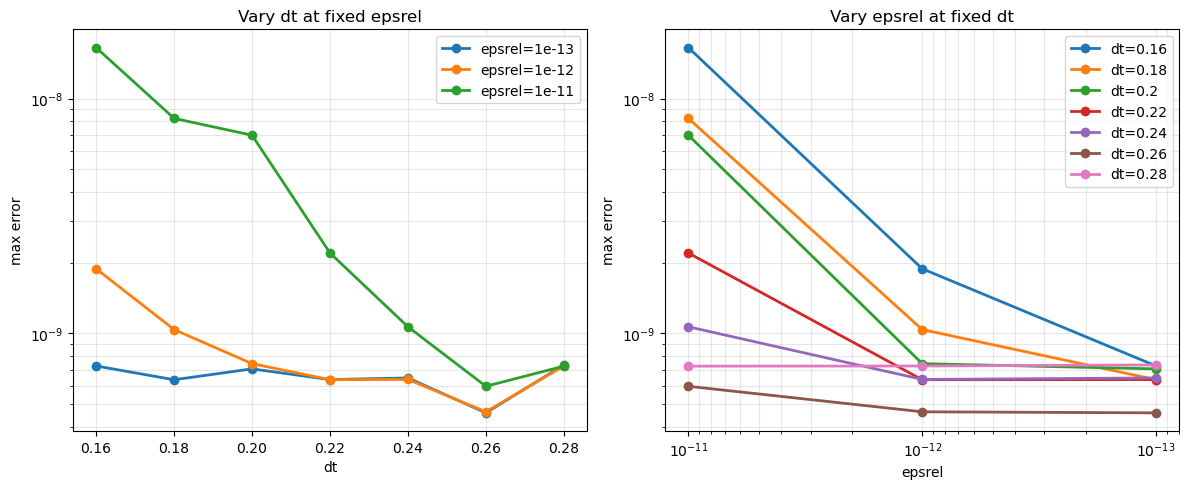

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# =====================================================
# Left: vary dt at fixed epsrel
# =====================================================

for epsrel in sorted(df["epsrel"].unique()):

    sub = df[df["epsrel"] == epsrel].sort_values("dt")

    ax[0].plot(
        sub["dt"],
        sub["max_error"],
        marker="o",
        linewidth=2,
        label=f"epsrel={epsrel:.0e}"
    )

ax[0].set_xlabel("dt")
ax[0].set_ylabel("max error")
ax[0].set_yscale("log")
ax[0].set_title("Vary dt at fixed epsrel")
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

# =====================================================
# Right: vary epsrel at fixed dt
# =====================================================

for dt in sorted(df["dt"].unique()):

    sub = df[df["dt"] == dt].sort_values("epsrel")

    ax[1].plot(
        sub["epsrel"],
        sub["max_error"],
        marker="o",
        linewidth=2,
        label=f"dt={dt}"
    )

ax[1].set_xlabel("epsrel")
ax[1].set_ylabel("max error")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].invert_xaxis()
ax[1].set_title("Vary epsrel at fixed dt")
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)


plt.tight_layout()
plt.show()

## 5. Convergence plots

Visualize how the numerical error changes with timestep and relative tolerance.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Converge tcut  (use best dt from Step 1)
# ─────────────────────────────────────────────────────────────────────────────
best_dt    = 0.26        # ← replace with converged value from Step 1
best_epsrel = 1e-12      # ← replace with converged value from Step 1
t_end_list = [6.0]   # extend to longer time to see memory cutoff effect clearly
tcut_list = [5.7, 6.0]  # ← choose a range around the expected memory time (from Step 1)
results_tcut = {}

tcut_table = []
for t_end in t_end_list:
    for tcut in tcut_list:

        result = run_oqupy_dynamics(
            H_sys,
            A,
            correlations,
            rho0,
            dt=best_dt,
            tcut=tcut,      # for this benchmark, avoid memory cutoff error
            epsrel=best_epsrel,
            t_end=t_end
        )

        times = result["times"]
        states = result["states"]
        coh = np.array([s[0,1] for s in states])

        gamma_R = alpha*np.log(1.0 + (omega_c*times)**2)

        # For the physical Hamiltonian H_int = sigma_z sum g(b+b†):
        coh_exact = coh[0] * np.exp(
            -1j*omega0*times
            -(Delta**2)*gamma_R
        )

        err = np.max(np.abs(coh - coh_exact))
        err_final = np.abs(coh[-1] - coh_exact[-1])
        print(tcut, t_end, err_final)
        tcut_table.append([f"tcut={tcut}, t_end={t_end} -> max error = {err}"])

print(f"for dt = {best_dt} and epsrel = {best_epsrel}, we get:")
for row in tcut_table:
    print(row)

--> PT-TEMPO computation:
100.0%   23 of   23 [########################################] 00:00:01
Elapsed time: 1.3s
--> Compute dynamics:
100.0%   23 of   23 [########################################] 00:00:00
Elapsed time: 0.8s
5.7 6.0 7.91565476527088e-09
--> PT-TEMPO computation:
100.0%   23 of   23 [########################################] 00:00:01
Elapsed time: 1.2s
--> Compute dynamics:
100.0%   23 of   23 [########################################] 00:00:00
Elapsed time: 0.8s
6.0 6.0 7.915561949567128e-09
for dt = 0.26 and epsrel = 1e-12, we get:
['tcut=5.7, t_end=6.0 -> max error = 7.91565476527088e-09']
['tcut=6.0, t_end=6.0 -> max error = 7.915561949567128e-09']


## 6. Memory cutoff scan

With timestep and tolerance fixed, vary the memory cutoff to identify the stable regime.